In [7]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import ipywidgets as widgets
from ipywidgets import interact
from ipywidgets import interact_manual

In [8]:
data = pd.read_csv('manipulated_data.csv')

## Top 200 Movies based on IMDB and No. of Reviews

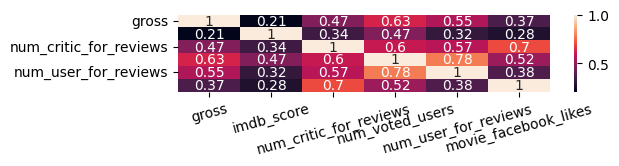

In [36]:
# a look at rating metrics' correlation with 'gross'

plt.rcParams['figure.figsize']=(6,1)
sns.heatmap(data[['gross','imdb_score','num_critic_for_reviews','num_voted_users','num_user_for_reviews','movie_facebook_likes']].corr(),annot=True)
plt.xticks(rotation=15)
plt.show()


In [ ]:
#DEFINE FUNCTIONS THAT COMBINE TWO COLUMNS WITH CONSIDERATION OF HIGHS AND LOWS IN EACH COLUMN

def f_of_omega(omega,col1,col2):
    f=(col1*omega)+(col2*(1-omega))
    return f

def L_of_omega(omega,col1,col2):
    vector=f_of_omega(omega,col1,col2)
    L=(1/len(vector))*sum((vector-vector.mean())**2)
    return L

def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

def min_L_of_omega_array(c1,c2,n=1_001):
    omega_array=np.linspace(0,1,n,endpoint=True)
    Loss_array=list()
    c1=normalize(c1)
    c2=normalize(c2)
    for i in range(len(omega_array)):
        Loss=L_of_omega(omega_array[i],c1,c2)
        Loss_array.append(Loss)
        #print(f'loss: {Loss}, omega: {omega_array[i]}')
    Loss_array=np.array(Loss_array)
    indx=Loss_array.argmin()
    min_loss_omega=omega_array[Loss_array.argmin()]
    return min_loss_omega


In [ ]:
#THE CORRELATION BETWEEN 'gross' AND 'num_voted_users': .63, WAS HIGHER THAN BETWEEN 'gross' and 'imdb_score': .21.
#each column can be weighted accordingly
importance={'imdb_score':0.3,'num_voted_users':0.7}

pd.set_option('display.max_rows',None)
import warnings
warnings.filterwarnings('ignore')

top_200 = data[['movie_title', 'imdb_score', 'num_voted_users']]
omega = min_L_of_omega_array(top_200['imdb_score'].to_numpy(), top_200['num_voted_users'].to_numpy())
#print('omega: '.upper(),omega)
top_200['sort_col'] = f_of_omega(omega,normalize(top_200['imdb_score'].to_numpy())*importance.get('imdb_score',1),normalize(top_200['num_voted_users'].to_numpy())*importance.get('num_voted_users',1))
top_200 = top_200.sort_values(by="sort_col", ascending=False)
n=200
top_200['movie_title'].head(n).values

array(['The Shawshank Redemption', 'The Dark Knight', 'Inception',
       'Fight Club', 'Pulp Fiction', 'Forrest Gump',
       'The Lord Of The Rings: The Fellowship Of The Ring',
       'The Lord Of The Rings: The Return Of The King', 'The Matrix',
       'The Godfather', 'The Dark Knight Rises',
       'The Lord Of The Rings: The Two Towers', 'Se7En', 'The Avengers',
       'Gladiator', 'Batman Begins', 'Django Unchained', 'Interstellar',
       'Star Wars: Episode Iv - A New Hope', 'The Silence Of The Lambs',
       'Saving Private Ryan', 'Inglourious Basterds', 'Avatar',
       'The Departed', "Schindler'S List", 'Memento', 'The Prestige',
       'Star Wars: Episode V - The Empire Strikes Back',
       'American Beauty',
       'Pirates Of The Caribbean: The Curse Of The Black Pearl',
       'The Godfather: Part Ii', 'V For Vendetta', 'American History X',
       'The Green Mile', 'Titanic', 'Shutter Island',
       'The Wolf Of Wall Street', 'Terminator 2: Judgment Day',
       'T

## Top Foreign Movies

In [43]:
n=15
plot1=data.loc[data['english']=='Foreign'].sort_values(by='gross',ascending=False).reset_index(drop=True)
plot1=plot1[['movie_title','language','gross']].head(n)
display(plot1.style.background_gradient(cmap='Oranges'))


,movie_title,language,gross
0,"Crouching Tiger, Hidden Dragon",Mandarin,128.067808
1,March Of The Penguins,French,77.413017
2,The Interpreter,Aboriginal,72.515360
3,Apocalypto,Maya,50.859889
4,The Legend Of Zorro,Spanish,45.356386
5,Instructions Not Included,Spanish,44.456509
6,Pan'S Labyrinth,Spanish,37.623143
7,Amélie,French,33.201661
8,Rumble In The Bronx,Cantonese,32.333860
9,The Secret In Their Eyes,Spanish,20.167424


## Top 10 Directors

In [50]:
n=10


data['movie_title']=data['movie_title'].str.strip().str.title()
data['director_name']=data['director_name'].str.strip().str.title()
data=data.drop_duplicates(subset='movie_title',keep='first')
num_rows=data.shape[0]
num_directors=data['director_name'].nunique()
print(f"There are {num_rows} movies, and {num_directors} directors.")
print(f"The top {n} directors are:")
tops=data['director_name'].value_counts()
pd.DataFrame({'Director':tops.index,'Number of Movies':tops.values}).head(n).style.background_gradient(cmap='Purples')


There are 3786 movies, and 1750 directors.
The top 10 directors are:


,Director,Number of Movies
0,Steven Spielberg,25
1,Woody Allen,19
2,Clint Eastwood,19
3,Martin Scorsese,16
4,Ridley Scott,16
5,Renny Harlin,15
6,Spike Lee,15
7,Steven Soderbergh,15
8,Tim Burton,14
9,Robert Zemeckis,13


## Year wise Top 10 Movies

In [53]:
@interact
def yearwise_top_n(years=data['title_year'].value_counts().index,n=10):
    top_year=data.loc[data['title_year']==years][['movie_title','gross']].sort_values(by='gross',ascending=False).reset_index(drop=True)
    display(top_year.head(n).style.background_gradient(cmap='autumn'))

interactive(children=(Dropdown(description='years', options=(2002, 2006, 2005, 2008, 2009, 2004, 2001, 2011, 2…